# Housing ML Model Proof-Of-Concept
## API Calls
to noise, pollution, crime, and housing price index datasets

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(dataset_code):
    url = f"{EUROSTAT_BASE}/{dataset_code}"
    params = {"format": "JSON", "lang": "en"}
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

noise = get_stat("ilc_mddw04")
pollution = get_stat("ilc_mddw05")
crime = get_stat("ilc_mddw06")
hpi = get_stat("prc_hpi_a")
happy = get_stat("ilc_pw01")

df_noise = eurostat_to_df(noise)
df_pollution = eurostat_to_df(pollution)
df_crime = eurostat_to_df(crime)
df_hpi = eurostat_to_df(hpi)
df_happy = eurostat_to_df(happy)

df_noise.to_csv("noise.csv", index=False)
df_pollution.to_csv("pollution.csv", index=False)
df_crime.to_csv("crime.csv", index=False)
df_hpi.to_csv("hpi.csv", index=False)
df_happy.to_csv("happy.csv", index=False)

## Clean Datasets

In [2]:
def clean_df(df, value_col):
    """Standardise column names, drop null values, etc."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[df['geo'].str[0:4] != 'Euro']
    df["year"] = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_noise_clean = clean_df(df_noise, "noise_rate")
df_pollution_clean = clean_df(df_pollution, "pollution_rate")
df_crime_clean = clean_df(df_crime, "crime_rate")
df_hpi_clean = clean_df(df_hpi, "hpi_weight")
df_happy_clean = clean_df(df_happy, "happy_rate")

In [3]:
# hpi dataset cleaning for weight column (had to do this seperately because of the 'total' purchase column)
purchase_col = [c for c in df_hpi.columns if "purch" in c]

if purchase_col:
    purchase_col = purchase_col[0]
    df_hpi_total = df_hpi[df_hpi[purchase_col].str.lower().str.contains("total")].copy()
else:
    df_hpi_total = df_hpi.copy()

df_hpi_total = df_hpi_total[df_hpi_total['unit'] == 'Annual average rate of change']
df_hpi_clean = clean_df(df_hpi_total, "hpi_weight")
df_hpi_clean.head(10)

,freq,purchase,unit,geo,year,hpi_weight
1744,Annual,Total,Annual average rate of change,Belgium,2006,9.8
1745,Annual,Total,Annual average rate of change,Belgium,2007,7.8
1746,Annual,Total,Annual average rate of change,Belgium,2008,4.3
1747,Annual,Total,Annual average rate of change,Belgium,2009,-0.4
1748,Annual,Total,Annual average rate of change,Belgium,2010,2.3
1749,Annual,Total,Annual average rate of change,Belgium,2011,3.6
1750,Annual,Total,Annual average rate of change,Belgium,2012,2.4
1751,Annual,Total,Annual average rate of change,Belgium,2013,1.5
1752,Annual,Total,Annual average rate of change,Belgium,2014,-0.3
1753,Annual,Total,Annual average rate of change,Belgium,2015,1.8


In [4]:
# clean life satisfaction dataset
df_happy_clean = df_happy_clean[df_happy_clean['age'] == 'From 16 to 29 years']
df_happy_clean = df_happy_clean[df_happy_clean['sex'] == 'Total']
df_happy_clean = df_happy_clean[df_happy_clean['isced11'] == 'Tertiary education (levels 5-8)']


In [5]:
df_noise_clean.to_csv("noise_clean.csv", index=False)
df_pollution_clean.to_csv("pollution_clean.csv", index=False)
df_crime_clean.to_csv("crime_clean.csv", index=False)
df_hpi_clean.to_csv("hpi_clean.csv", index=False)
df_happy_clean.to_csv("happy_clean.csv", index=False)

In [6]:
# merging on common columns without aggregating

df_crime_clean = df_crime_clean.drop(columns=["freq", "unit"])
df_noise_clean = df_noise_clean.drop(columns=["freq", "unit"])
df_pollution_clean = df_pollution_clean.drop(columns=["freq", "unit"])
df_hpi_clean = df_hpi_clean.drop(columns=["freq", "purchase", "unit"])
df_happy_clean = df_happy_clean.drop(columns=["freq", "statinfo", "unit", "isced11", "life_sat"])

df_merged = df_crime_clean.merge(df_noise_clean, on=["deg_urb", "rskpovth", "geo", "year"])
df_merged = df_merged.merge(df_pollution_clean, on=["deg_urb", "rskpovth", "geo", "year"])
df_merged = df_merged.merge(df_hpi_clean, on=["geo", "year"])
df_merged = df_merged.merge(df_happy_clean, on=["geo", "year"])

df_merged = df_merged.drop(columns=["sex", 'age'])
df_merged.to_csv("merged2.csv", index=False)

### Feature Engineering

In [7]:
df = pd.read_csv("merged2.csv")
df = pd.get_dummies(df, columns=["deg_urb", "rskpovth"], drop_first=True)
df_model = (
    df.groupby(['geo', 'year'], as_index=False)
    [['crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight', 'happy_rate']].mean()
)
'''
df['crime_ru'] = df['crime_rate'] * df['deg_urb_Rural areas']
df['poll_ru'] = df['pollution_rate'] * df['deg_urb_Rural areas']
df['noise_ru'] = df['noise_rate'] * df['deg_urb_Rural areas']

df['crime_sub'] = df['crime_rate'] * df['deg_urb_Towns and suburbs']
df['poll_sub'] = df['pollution_rate'] * df['deg_urb_Towns and suburbs']
df['noise_sub'] = df['noise_rate'] * df['deg_urb_Towns and suburbs']
'''
df.to_csv("merged2.csv", index=False)

## Linear Regression

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
 
# loading data
df = pd.read_csv("merged2.csv")

In [9]:
# linreg functions
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

def line_of_best_fit(X, y):
    """
    Args: 
        X (array): either 1-d or 2-d
        y (array): 1-d

    Returns:
        b (array): vector containing coefficients for line of best fit including intercept
    """
    X_bias = add_bias_column(X)
    b = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)
    return b

def linreg_predict(Xnew, ynew, b):
    """
    Args: 
        Xnew (array either 1-d or 2-d): includes all the $p$ predictor features, not including bias term
        ynew (1-d array) includes all corresponding response values to Xnew
        b (1-d array of length $p+1$): contains the coefficients from the `line_of_best_fit` function

    Returns:
        pred (dict): 4 key value pairs- ypreds (predicted values), resids (residuals/diffs), mse, r2
    """
    X_bias = add_bias_column(Xnew)
    ypreds = X_bias @ b
    resids = ypreds - ynew
    mse = np.mean(resids ** 2)
    r2 = r2_score(ynew, ypreds)
    preds = {'ypreds': ypreds, 'resids': resids, 'mse': mse, 'r2': r2}
    return preds

In [ ]:
cols = [
    'crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight',
    'deg_urb_Rural areas', 'deg_urb_Towns and suburbs'
]

X = np.array(df[cols])
y = np.array(df['happy_rate'])

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled  = scaler.transform(Xtest)
 
b = line_of_best_fit(Xtrain_scaled, ytrain)
results = linreg_predict(Xtest_scaled, ytest, b)

print("mse:", results['mse'])
print("r2: ", results['r2'])

mse: 0.15432411423349104
r2:  0.2707553798221567


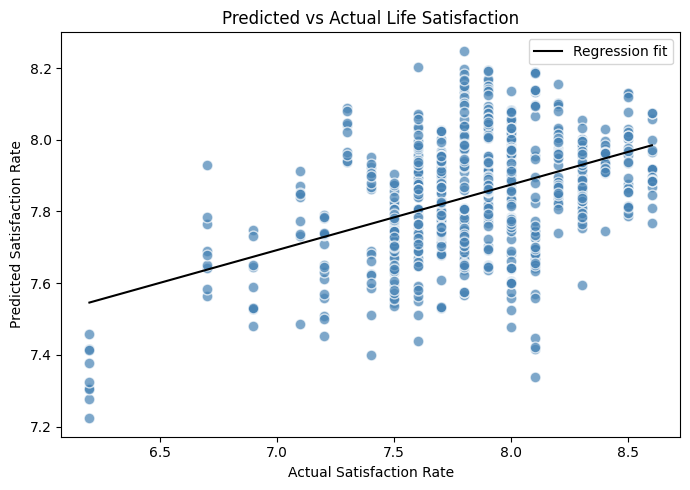

In [15]:
# get predictions on the full dataset
X_full = np.array(df[cols]).astype(float)
X_full_scaled = scaler.transform(X_full)
full_results = linreg_predict(X_full_scaled, y, b)
ypreds = full_results['ypreds']

# plot
plt.figure(figsize=(7, 5))
plt.scatter(y, ypreds, color='steelblue', edgecolors='white', s=60, alpha=0.7)

# best fit line through the scatter
m, c = np.polyfit(y, ypreds, 1)
x_line = np.linspace(y.min(), y.max(), 100)
plt.plot(x_line, m * x_line + c,
         color='black', linewidth=1.5, label='Regression fit')

plt.xlabel("Actual Satisfaction Rate")
plt.ylabel("Predicted Satisfaction Rate")
plt.title("Predicted vs Actual Life Satisfaction")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
def predict_satisfaction(crime, noise, pollution, hpi, is_rural, is_towns, b, scaler, feature_cols, df):
    """
    Args:
        crime (float): crime rate input
        noise (float): noise rate input
        pollution (float): pollution rate input
        hpi (float): housing price index input
        is_rural (bool): True if rural area
        is_towns (bool): True if towns/suburbs (both False = cities)
        is_below_60 (bool): True if below 60% median income
        is_total (bool): True if total income group
        b (array): coefficients from line_of_best_fit
        scaler (StandardScaler): fitted scaler
        feature_cols (list): feature column names used in model
        df (DataFrame): needed to compute geo_mean_happy and polynomial terms

    Returns:
        predicted satisfaction score (float)
    """

    # build input row in the same column order as feature_cols
    input_dict = {
        'crime_rate':                  crime,
        'noise_rate':                  noise,
        'pollution_rate':              pollution,
        'hpi_weight':                  hpi,
        'deg_urb_Rural areas':         is_rural,
        'deg_urb_Towns and suburbs':   is_towns,
    }

    X_input = np.array([input_dict[col] for col in feature_cols]).astype(float).reshape(1, -1)
    X_scaled = scaler.transform(X_input)
    X_bias = add_bias_column(X_scaled)
    prediction = (X_bias @ b)[0]

    print(f"Predicted life satisfaction score: {prediction:.2f}")
    return prediction


# example
predict_satisfaction(
    crime=20, noise=25, pollution=15, hpi=3.0,
    is_rural=False, is_towns=False,
    b=b, scaler=scaler, feature_cols=cols, df=df
)


Predicted life satisfaction score: 7.78


np.float64(7.778308027322673)

In [13]:
def show_country_stats(country_name, df):
    rows = df[df['geo'].str.lower() == country_name.strip().lower()]
    if rows.empty:
        print(f"Country '{country_name}' not found.")
        return

    latest_year = rows['year'].max()
    rows = rows[rows['year'] == latest_year]

    urb_tiers = {
        'Cities':            (False, False),
        'Towns and Suburbs': (False, True),
        'Rural Areas':       (True,  False),
    }

    print(f"\n{country_name}")
    for tier_name, (is_rural, is_towns) in urb_tiers.items():
        tier_rows = rows[
            (rows['deg_urb_Rural areas']       == is_rural) &
            (rows['deg_urb_Towns and suburbs'] == is_towns)
        ]
        if tier_rows.empty:
            continue
        r = tier_rows.iloc[0]
        print(f"\n  [{tier_name}]")
        print(f"    Crime rate:     {r['crime_rate']}")
        print(f"    Noise rate:     {r['noise_rate']}")
        print(f"    Pollution rate: {r['pollution_rate']}")
        print(f"    HPI weight:     {r['hpi_weight']}")

show_country_stats("Belgium", df)


Belgium

  [Cities]
    Crime rate:     29.6
    Noise rate:     24.7
    Pollution rate: 29.2
    HPI weight:     2.3

  [Towns and Suburbs]
    Crime rate:     10.7
    Noise rate:     16.7
    Pollution rate: 9.9
    HPI weight:     2.3

  [Rural Areas]
    Crime rate:     9.1
    Noise rate:     12.5
    Pollution rate: 10.2
    HPI weight:     2.3
